In [ ]:
localdisk = "base_path"
dat_path = "img_path"
ccf_path = "ccf_path"
template_path =  f"{dat_path}/template_dir"

In [ ]:
# import wide-field images

import glob
import numpy as np
from tifffile import imread

frames = 1600


filelist1 = sorted(glob.glob("1frame_tif_path/*.tif"))

if not filelist1:
    raise FileNotFoundError("tif files not found")

images1 = [imread(file) for file in filelist1]

all_tif1 = np.stack(images1, axis=0)

print("Combined array1 shape:", all_tif1.shape)  # (frames, height, width)

Combined array1 shape: (17600, 256, 270)


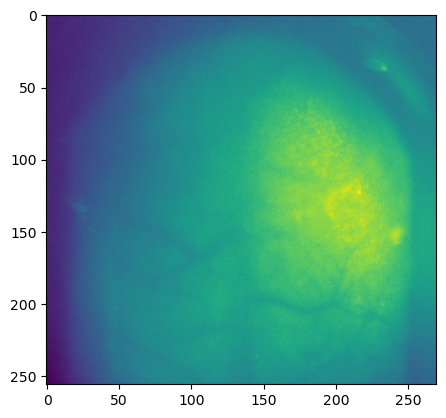

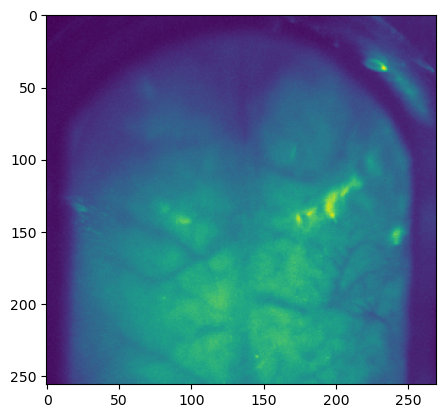

In [ ]:
# visualize your 1st frames

import matplotlib.pyplot as plt

plt.imshow(all_tif1[1600])
plt.show()

plt.imshow(all_tif1[1601])
plt.show()

In [ ]:
# delete 0th cycle

all_tif1 = all_tif1[1600:]
print(all_tif1.shape)

(16000, 256, 270)


In [ ]:
# if you have to delete more

#all_tif1 = np.concatenate((all_tif1[1600:11200], all_tif1[12800:]), axis=0)
#print(all_tif1.shape)

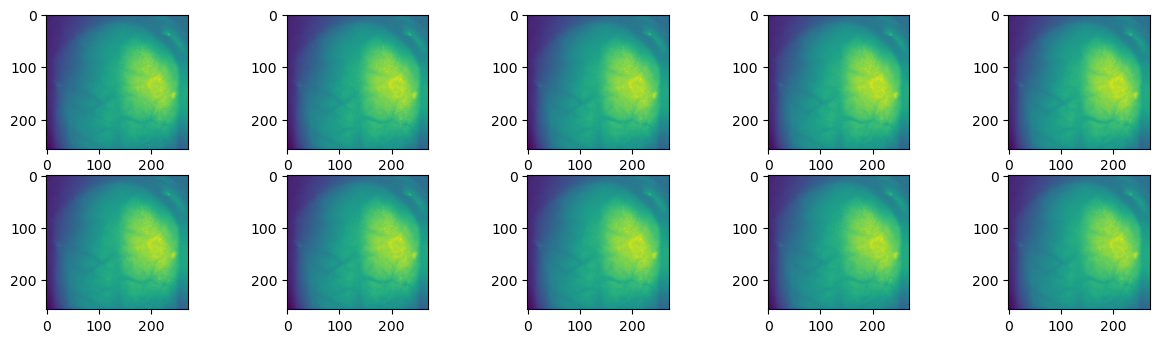

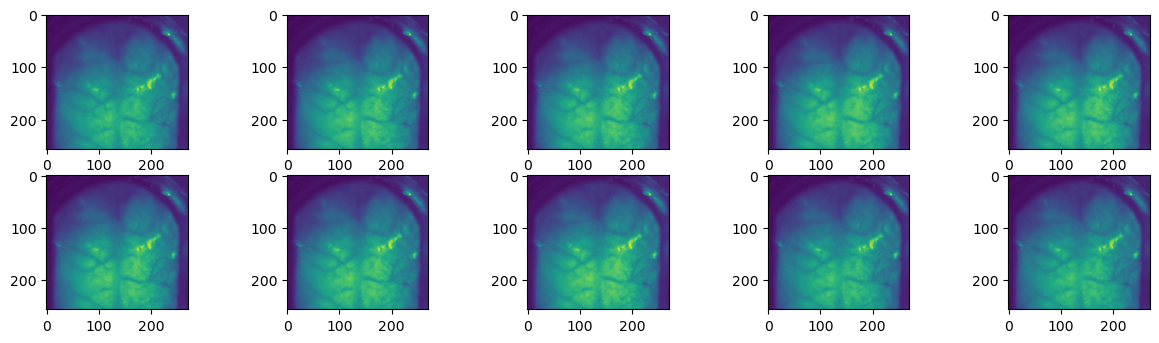

In [ ]:
# visualize all the cycle you did

import matplotlib.pyplot as plt

ex_nums = 10

plt.figure(figsize=(15, 8))  # width 15 inch, height 8 inch
for ex in range(ex_nums):  # Start from 1 and end at 15 (inclusive)
  plt.subplot(4, 5, ex+1)
  plt.imshow(all_tif1[ex*frames])
  # ... rest of your code
plt.show()

plt.figure(figsize=(15, 8))  # width 15 inch, height 8 inch
for ex in range(ex_nums):  # Start from 1 and end at 15 (inclusive)
  plt.subplot(4, 5, ex+1)
  plt.imshow(all_tif1[(ex+1)*frames-1])
  # ... rest of your code
plt.show()

In [ ]:
# make analysis forlder

import os
from wfield import *

os.mkdir("localdisk")

base_path = "localdisk"
path = pjoin(base_path, "dat")
os.mkdir(path)

In [ ]:
# save images cycle by cycle

import tifffile as tiff

frames = 1600

ex_in1 = int(all_tif1.shape[0] / frames)
for ex in range(ex_in1):
    subfolder = pjoin(path, f"ex{ex}")
    os.mkdir(subfolder)
    file_path = os.path.join(subfolder, f"ex{ex}.tif")
    tiff.imwrite(file_path, all_tif1[ex*frames:(ex+1)*frames])

In [ ]:
# save 1st frame to place landmarks in 3rd cording file

import tifffile as tiff

image_path = os.path.join(path, "1f.tif")
tiff.imwrite(image_path, all_tif1[0])

In [ ]:
# make function to visualize activities of ROIs you want to see in 1 cycle

import numpy as np
import matplotlib.pyplot as plt

def roi_setting(img_array):


    time_steps, height, width = img_array.shape

    # setting ROIs (y, x)
    roi1 = np.zeros((height, width), dtype=bool)
    roi1[200:230, 180:210] = 1

    rois = [roi1]


    roi_means = []
    for roi in rois:

        mean_values = np.array([np.mean(frame[roi]) for frame in img_array])
        roi_means.append(mean_values)


    roi_means = np.array(roi_means)

    print("average time course in ROIs:", roi_means.shape)  # (rois, frames)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_array[0], cmap='gray', interpolation='nearest')  # visualize first frame


    for idx, roi in enumerate(rois):
        #plt.contour(roi, colors=[f'C{idx}'], linewidths=1.5, label=f'ROI {idx + 1}')
        plt.contour(roi, colors='red', linewidths=3, label=f'ROI {idx + 1}')

    plt.show()

    return roi_means

In [ ]:
# make function to visualize activities of a ROI you want to see in your whole experient

import numpy as np
import matplotlib.pyplot as plt

frames = 800

def roi_calc(img_array):


    time_steps, height, width = img_array.shape

    roi = np.zeros((height, width), dtype=bool)
    roi[200:230, 180:210] = 1  # (y, x)
    mean_values = np.array([np.mean(frame[roi]) for frame in img_array])

    return mean_values

In [ ]:
# set time frames

# start time
start_value = 0.0

# increase per frame
increment = 0.05

# number of frames
count = 800

t = [start_value + i * increment for i in range(count)]

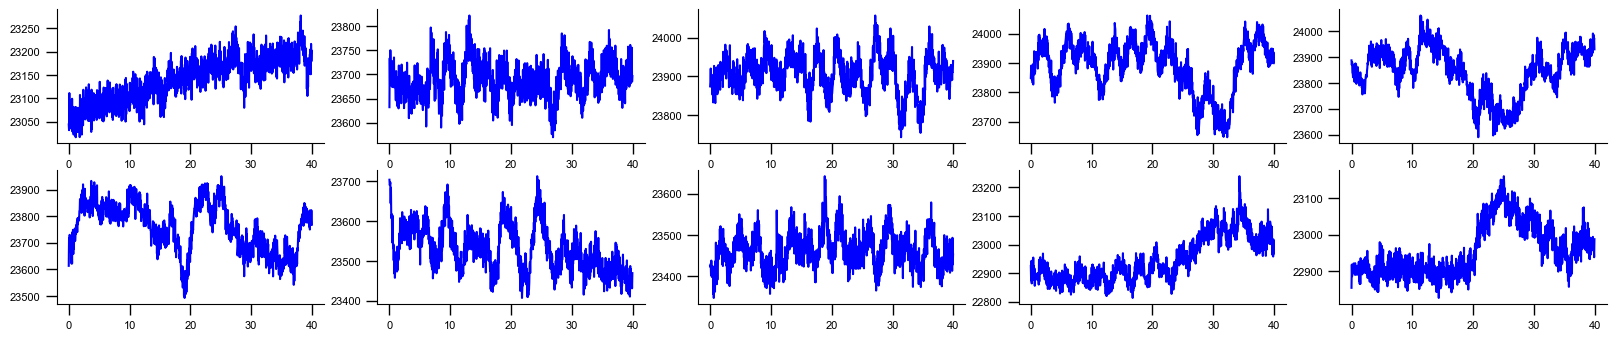

In [ ]:
# show fluorescence of your ROI with blue excitation in your whole experiment

plt.figure(figsize=(20, 8))  # width 20 inch, height 8 inch

for ex in range(int(all_tif1.shape[0]/(frames*2))):
    mean_values = roi_calc(all_tif1[ex*frames*2:(ex+1)*frames*2][::2])
    plt.subplot(4, 5, ex+1)
    plt.plot(t[:frames], mean_values, color='blue')
    #plt.axvspan(20, 30, color='red', alpha=0.3)

plt.show()

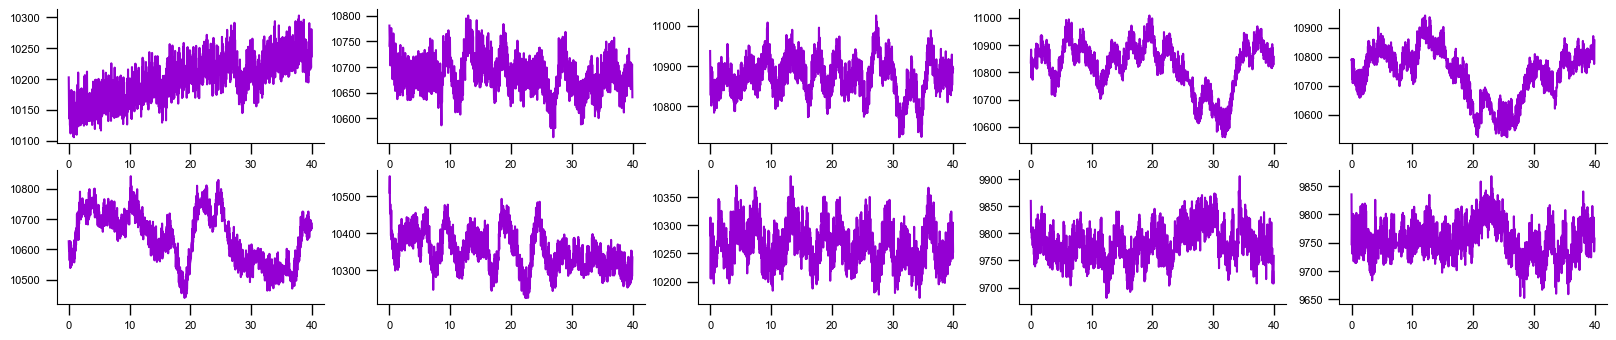

In [ ]:
# show fluorescence of your ROI for violet excitation in your whole experiment

plt.figure(figsize=(20, 8))  # width 20 inch, height 8 inch

for ex in range(int(all_tif1.shape[0]/(frames*2))):
    mean_values = roi_calc(all_tif1[ex*frames*2:(ex+1)*frames*2][1::2])
    plt.subplot(4, 5, ex+1)
    plt.plot(t[:frames], mean_values, color='darkviolet')
    #plt.axvspan(20, 30, color='red', alpha=0.3)

plt.show()

各ROIの経時変化平均値: (1, 800)


C:\Users\user\AppData\Local\Temp\ipykernel_9680\3975532313.py:34: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(roi, colors='red', linewidths=3, label=f'ROI {idx + 1}')


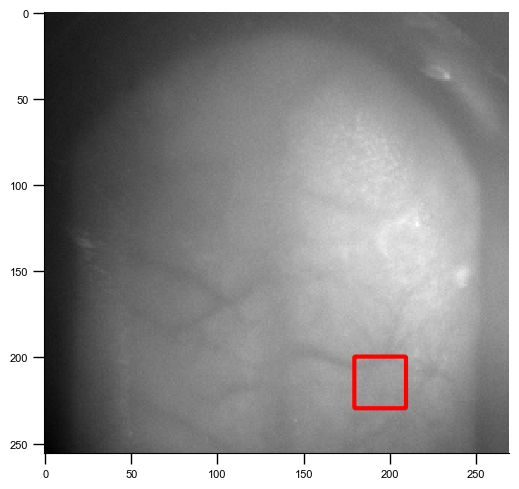

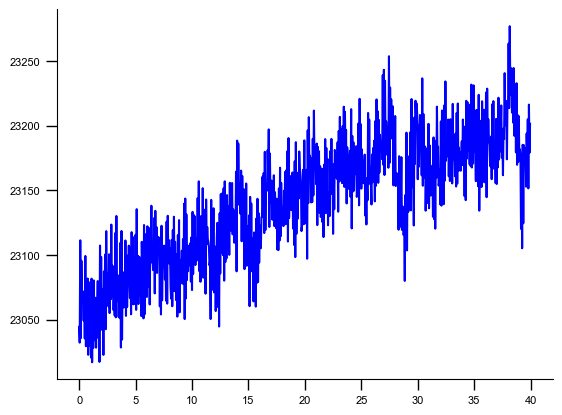

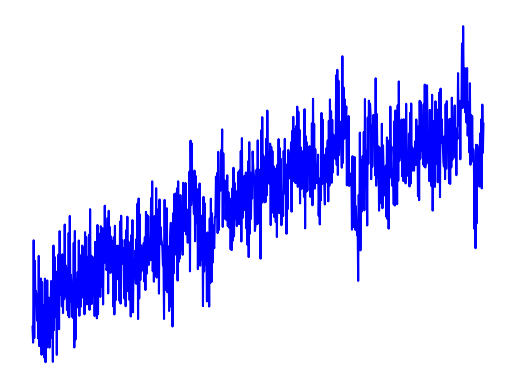

In [ ]:
# show your ROIs and fluorescence with blue excitation in your 1 experiment

frames = 800

roi_means = roi_setting(all_tif1[:2*frames][::2])
for i in range(roi_means.shape[0]):
    plt.plot(t[:frames], roi_means[i][:frames], color='blue')
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(t[:frames], roi_means[i][:frames], color='blue')

    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

各ROIの経時変化平均値: (1, 800)


C:\Users\user\AppData\Local\Temp\ipykernel_9680\3975532313.py:34: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(roi, colors='red', linewidths=3, label=f'ROI {idx + 1}')


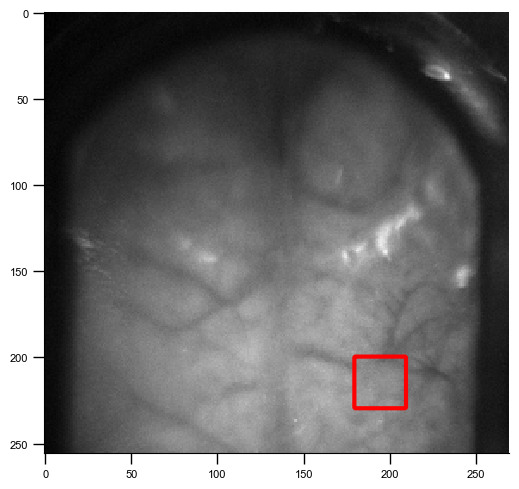

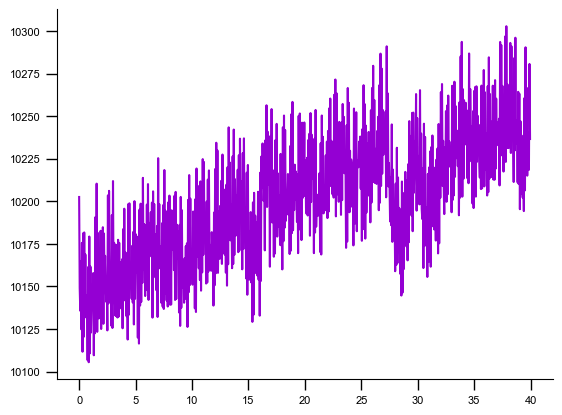

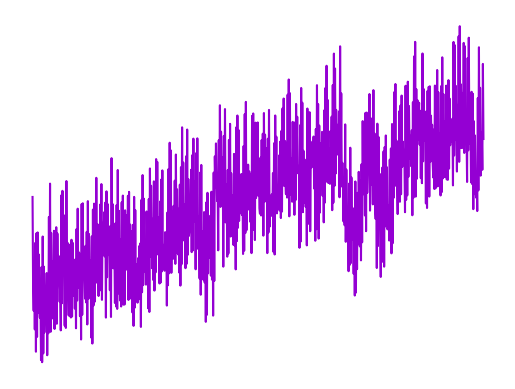

In [ ]:
# show your ROIs and fluorescence with violet excitation in your 1 experiment

roi_means = roi_setting(all_tif1[:2*frames][1::2])
for i in range(roi_means.shape[0]):
    plt.plot(t[:frames], roi_means[i][:frames], color='darkviolet')
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(t[:frames], roi_means[i][:frames], color='darkviolet')
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

In [ ]:
#tiff.imwrite(os.path.join(path, "250428_01_ex1_470nm.tif"), all_tif1[1600:3200][::2])
#tiff.imwrite(os.path.join(path, "250428_01_ex1_405nm.tif"), all_tif1[1600:3200][1::2])